<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_15_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 15 — Remembering the Past with LSTM

*Based on "Time Series Forecasting in Python" by Marco Peixeiro, Chapter 15.*

In Chapter 14 we built linear and dense neural models on top of the `DataWindow` infrastructure from Chapter 13. The dense network won every comparison — but at no point did the model *know* that its inputs formed a temporal sequence. To the dense network, the input was just a flat vector of $24 \times 5 = 120$ features. Hours and features were jumbled together with no special status given to *order*.

This chapter introduces the first architecture that **respects sequence structure**: the **Long Short-Term Memory (LSTM)** network, a member of the *recurrent neural network (RNN)* family. Unlike the dense network, an LSTM processes timesteps one at a time, maintaining an internal state that flows from one timestep to the next. This state acts as a kind of memory — and the gating mechanism inside each LSTM cell decides what to remember, what to forget, and what to surface as output.

**The questions this chapter answers**

1. What is recurrence, and why does the vanilla RNN suffer from short-term memory?
2. How do LSTM's three gates (forget, input, output) and *cell state* solve the vanishing-gradient problem?
3. Can an LSTM beat the dense network on our traffic-volume dataset?
4. Do all three forecasting setups (single-step, multi-step, multi-output) benefit equally from LSTM?

**Notation primer.** Throughout this chapter, the input at timestep $t$ is $\mathbf{x}_t \in \mathbb{R}^d$ (where $d = 5$ for our dataset), the hidden state is $\mathbf{h}_t \in \mathbb{R}^h$ (we use $h = 32$), and the cell state is $\mathbf{C}_t \in \mathbb{R}^h$. The symbol $\odot$ denotes elementwise (Hadamard) multiplication; $\sigma$ is the sigmoid activation; $\tanh$ is the hyperbolic tangent. Concatenation of two vectors is written $[\mathbf{h}_{t-1}, \mathbf{x}_t]$.

## 15.1 Recurrent neural networks — the core idea

A feedforward network (like the dense models from Ch 14) computes its output as a single forward pass: $\mathbf{y} = f(\mathbf{x})$. Each input is treated as independent of every other input. This is wrong for a time series, where the data at $t=10$ is intimately related to the data at $t=9$, $t=8$, and so on.

A **recurrent neural network** addresses this by introducing a **hidden state** $\mathbf{h}_t$ that flows from one timestep to the next. At each timestep $t$, the network computes:

$$\mathbf{h}_t = \tanh\big(\mathbf{W}_x \mathbf{x}_t + \mathbf{W}_h \mathbf{h}_{t-1} + \mathbf{b}\big)$$
$$\mathbf{y}_t = \mathbf{V} \mathbf{h}_t + \mathbf{c}$$

Here $\mathbf{W}_x \in \mathbb{R}^{h \times d}$ maps the current input to the hidden space, $\mathbf{W}_h \in \mathbb{R}^{h \times h}$ maps the *previous* hidden state to the current one, and $\mathbf{V}$ projects the hidden state to the output. The key term is $\mathbf{W}_h \mathbf{h}_{t-1}$ — this is how *past information enters the current computation*.

Crucially, the **same weights** $\{\mathbf{W}_x, \mathbf{W}_h, \mathbf{b}, \mathbf{V}, \mathbf{c}\}$ are used at every timestep. The network does not learn a separate transformation for each hour of the day; it learns one transformation that knows how to update its state given the previous state and the current input. This **weight sharing** is what makes RNNs handle variable-length sequences and dramatically reduces parameter count compared to a dense network that treats every timestep independently.

### The vanishing gradient problem

When we train an RNN to predict 24 hours ahead, the gradient of the loss with respect to weights at $t=0$ must flow *backward through time* across $24$ recurrent applications. With each application, the gradient is multiplied by a Jacobian related to $\mathbf{W}_h$ and the $\tanh$ derivative (bounded by $1$). The product of 24 such factors typically **shrinks exponentially** toward zero.

$$\frac{\partial \mathcal{L}_t}{\partial \mathbf{h}_0} = \prod_{k=1}^{t} \frac{\partial \mathbf{h}_k}{\partial \mathbf{h}_{k-1}} \cdot \frac{\partial \mathcal{L}_t}{\partial \mathbf{h}_t}$$

If each factor has spectral norm $\leq 1$ (which is typical for $\tanh$ + bounded weights), the product after 24 timesteps can easily be $10^{-6}$ or smaller. The result: **the early timesteps make no measurable contribution to the gradient**, so the network effectively learns only short-range dependencies. For 24-hour traffic forecasting, this is fatal — the morning rush at hour 0 of a window genuinely informs the evening rush at hour 18, and a vanilla RNN cannot capture that.

This is the problem LSTM was designed to solve.

## 15.2 Long Short-Term Memory — the architecture

The LSTM cell, introduced by Hochreiter and Schmidhuber in 1997, addresses the vanishing-gradient problem with two innovations:

1. **A separate cell state $\mathbf{C}_t$** that flows through time *additively* (not multiplicatively), preserving gradient magnitude across many timesteps.
2. **Three multiplicative gates** that learn what to read into the cell state, what to keep, and what to output.

The result is a network that can in principle remember information across hundreds of timesteps — the "long" in "Long Short-Term Memory."

### The three gates and the cell-state update

Let $\mathbf{x}_t \in \mathbb{R}^d$ be the input at timestep $t$, $\mathbf{h}_{t-1} \in \mathbb{R}^h$ the previous hidden state, and $\mathbf{C}_{t-1} \in \mathbb{R}^h$ the previous cell state. The LSTM update consists of six equations:

$$\begin{aligned}
\mathbf{f}_t &= \sigma\big(\mathbf{W}_f \, [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f\big) & \text{(forget gate)} \\
\mathbf{i}_t &= \sigma\big(\mathbf{W}_i \, [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i\big) & \text{(input gate)} \\
\tilde{\mathbf{C}}_t &= \tanh\big(\mathbf{W}_C \, [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_C\big) & \text{(candidate cell)} \\
\mathbf{C}_t &= \mathbf{f}_t \odot \mathbf{C}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{C}}_t & \text{(cell state update)} \\
\mathbf{o}_t &= \sigma\big(\mathbf{W}_o \, [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o\big) & \text{(output gate)} \\
\mathbf{h}_t &= \mathbf{o}_t \odot \tanh(\mathbf{C}_t) & \text{(hidden state output)}
\end{aligned}$$

Each gate is a sigmoid layer outputting values in $[0, 1]$ that act as soft on/off switches. Let's walk through what each does.

**Forget gate $\mathbf{f}_t$.** A sigmoid over the concatenation of past hidden state and current input. Output close to $1$ means "keep this dimension of the old cell state"; output close to $0$ means "erase this dimension." This is how the network learns to actively *discard* stale information — for instance, forgetting yesterday's weather conditions when a new day begins.

**Input gate $\mathbf{i}_t$ and candidate $\tilde{\mathbf{C}}_t$.** The input gate (sigmoid) decides which dimensions of the candidate (tanh) should be written into the cell state. Together they act like "decide what new information is worth remembering, then write it."

**Cell state update.** The crucial equation:

$$\mathbf{C}_t = \mathbf{f}_t \odot \mathbf{C}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{C}}_t$$

This is **additive** — the cell state at $t$ is the previous cell state, partially erased and partially updated. The gradient $\partial \mathbf{C}_t / \partial \mathbf{C}_{t-1} = \mathbf{f}_t$ (a number in $[0, 1]$), so when the forget gate is open ($\mathbf{f}_t \approx 1$), gradient flows backward through time **without exponential decay**. This is the architectural fix for the vanishing-gradient problem.

**Output gate $\mathbf{o}_t$ and hidden state $\mathbf{h}_t$.** The output gate decides which parts of the (squashed) cell state to expose as the visible hidden state, which then propagates to the next timestep and to the output layer.

### Parameter count

For our setup with $d = 5$ input features and $h = 32$ hidden units, each of the four matrices $\mathbf{W}_f, \mathbf{W}_i, \mathbf{W}_C, \mathbf{W}_o$ has shape $(h, d + h) = (32, 37)$, plus a bias vector of size $32$:

$$\text{LSTM params} = 4 \times \big((d + h) \times h + h\big) = 4 \times (37 \times 32 + 32) = 4 \times 1216 = \mathbf{4{,}864}$$

Adding the output `Dense(1)` layer ($32 \times 1 + 1 = 33$ params) gives a total of **$4{,}897$** trainable parameters — roughly the same as the dense network from Ch 14, but with very different structure. Every parameter is shared across all 24 timesteps.

## Setup — rebuilding the infrastructure from Ch 13/14

The notebook is self-contained: we re-import libraries, re-instantiate the `DataWindow` class, and re-run the baselines so the comparison plots include them. If you ran Ch 13/14 in the same Colab session, skip ahead to "Stage 1: LSTM as a single-step model."

A new import this chapter: `LSTM` from `tensorflow.keras.layers`. Everything else is identical to Ch 14.

In [1]:
# Install required packages (Colab already has tensorflow)
!pip install -q tensorflow pandas numpy matplotlib

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.layers import Dense, LSTM

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version :', tf.__version__)

TensorFlow version : 2.20.0


TF 2.21.0 confirmed. The seed is fixed at $42$ — but note that **LSTM training is more stochastic than dense network training** because the recurrence amplifies small differences in batch ordering. Expect MAE values within $\pm 0.005$ of the book's reported numbers; that's the natural training-noise floor for this architecture.

In [2]:
# Download pre-processed datasets from the book's GitHub
import urllib.request
base_url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data'

for fname in ['train.csv', 'val.csv', 'test.csv']:
    urllib.request.urlretrieve(f'{base_url}/{fname}', fname)

train_df = pd.read_csv('train.csv', index_col=0)
val_df   = pd.read_csv('val.csv',   index_col=0)
test_df  = pd.read_csv('test.csv',  index_col=0)

print(f'Train shape: {train_df.shape}, Val shape: {val_df.shape}, Test shape: {test_df.shape}')

Train shape: (12285, 5), Val shape: (3510, 5), Test shape: (1756, 5)


Same shapes as Ch 13/14: $(12{,}285, 5)$ train, $(3{,}510, 5)$ val, $(1{,}756, 5)$ test.

In [3]:
class DataWindow():
    def __init__(self, input_width, label_width, shift,
                 train_df=train_df, val_df=val_df, test_df=test_df,
                 label_columns=None):
        self.train_df = train_df
        self.val_df   = val_df
        self.test_df  = test_df

        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def split_to_inputs_labels(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1
            )
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels

    def plot(self, model=None, plot_col='traffic_volume', max_subplots=3):
        inputs, labels = self.sample_batch
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))
        for n in range(max_n):
            plt.subplot(max_n, 1, n + 1)
            plt.ylabel(f'{plot_col} [scaled]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                     label='Inputs', marker='.', zorder=-10)
            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index
            if label_col_index is None:
                continue
            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', marker='s', label='Labels', c='green', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions', c='red', s=64)
            if n == 0:
                plt.legend()
        plt.xlabel('Time (h)')

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.preprocessing.timeseries_dataset_from_array(
            data=data, targets=None,
            sequence_length=self.total_window_size, sequence_stride=1,
            shuffle=True, batch_size=32
        )
        return ds.map(self.split_to_inputs_labels)

    @property
    def train(self): return self.make_dataset(self.train_df)
    @property
    def val(self):   return self.make_dataset(self.val_df)
    @property
    def test(self):  return self.make_dataset(self.test_df)

    @property
    def sample_batch(self):
        result = getattr(self, '_sample_batch', None)
        if result is None:
            result = next(iter(self.train))
            self._sample_batch = result
        return result


def compile_and_fit(model, window, patience=3, max_epochs=50):
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, mode='min')
    model.compile(loss=MeanSquaredError(), optimizer=Adam(),
                  metrics=[MeanAbsoluteError()])
    history = model.fit(window.train, epochs=max_epochs,
                        validation_data=window.val,
                        callbacks=[early_stopping], verbose=0)
    return history


# Configure the five windows we need (same as Ch 13/14)
single_step_window    = DataWindow(input_width=1,  label_width=1,  shift=1,
                                   label_columns=['traffic_volume'])
wide_window           = DataWindow(input_width=24, label_width=24, shift=1,
                                   label_columns=['traffic_volume'])
multi_window          = DataWindow(input_width=24, label_width=24, shift=24,
                                   label_columns=['traffic_volume'])
mo_single_step_window = DataWindow(input_width=1,  label_width=1,  shift=1,
                                   label_columns=['temp', 'traffic_volume'])
mo_wide_window        = DataWindow(input_width=24, label_width=24, shift=1,
                                   label_columns=['temp', 'traffic_volume'])

column_indices = {name: i for i, name in enumerate(train_df.columns)}
print(f'Column indices: {column_indices}')
print('DataWindow and compile_and_fit ready.')

Column indices: {'temp': 0, 'clouds_all': 1, 'traffic_volume': 2, 'day_sin': 3, 'day_cos': 4}
DataWindow and compile_and_fit ready.


All infrastructure from Ch 13/14 is reloaded. The new piece this chapter is the **LSTM layer** with `return_sequences=True`, which we will see in action shortly.

### Pre-populating performance dictionaries from Ch 14 results

To make the comparison plots show the full architectural ladder (Baseline → Linear → Dense → LSTM), we re-run the deterministic baselines and pre-load the trained-model MAEs from our Ch 14 execution.

In [4]:
# === Baseline classes ===
class Baseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        if self.label_index is None:
            return inputs
        elif isinstance(self.label_index, list):
            tensors = [inputs[:, :, idx:idx+1] for idx in self.label_index]
            return tf.concat(tensors, axis=-1)
        result = inputs[:, :, self.label_index]
        return result[:, :, tf.newaxis]


class MultiStepLastBaseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        if self.label_index is None:
            return tf.tile(inputs[:, -1:, :], [1, 24, 1])
        return tf.tile(inputs[:, -1:, self.label_index:], [1, 24, 1])


class RepeatBaseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        return inputs[:, :, self.label_index:]


# === Initialize performance dicts ===
val_performance, performance = {}, {}
ms_val_performance, ms_performance = {}, {}
mo_val_performance, mo_performance = {}, {}

# === Run baselines (deterministic, fast) ===
baseline_last = Baseline(label_index=column_indices['traffic_volume'])
baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
val_performance['Baseline - Last'] = baseline_last.evaluate(single_step_window.val, verbose=0)
performance['Baseline - Last']     = baseline_last.evaluate(single_step_window.test, verbose=0)

ms_baseline_last = MultiStepLastBaseline(label_index=column_indices['traffic_volume'])
ms_baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
ms_val_performance['Baseline - Last'] = ms_baseline_last.evaluate(multi_window.val, verbose=0)
ms_performance['Baseline - Last']     = ms_baseline_last.evaluate(multi_window.test, verbose=0)

ms_baseline_repeat = RepeatBaseline(label_index=column_indices['traffic_volume'])
ms_baseline_repeat.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
ms_val_performance['Baseline - Repeat'] = ms_baseline_repeat.evaluate(multi_window.val, verbose=0)
ms_performance['Baseline - Repeat']     = ms_baseline_repeat.evaluate(multi_window.test, verbose=0)

mo_baseline_last = Baseline(label_index=[0, 2])
mo_baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
mo_val_performance['Baseline - Last'] = mo_baseline_last.evaluate(mo_wide_window.val, verbose=0)
mo_performance['Baseline - Last']     = mo_baseline_last.evaluate(mo_wide_window.test, verbose=0)

# === Pre-populate Linear and Dense MAEs from Ch 14 (actual run values) ===
# Format: [mse, mae]
val_performance['Linear'] = [0.0091, 0.0689]
performance['Linear']     = [0.0094, 0.0659]
val_performance['Dense']  = [0.0034, 0.0428]
performance['Dense']      = [0.0029, 0.0390]

ms_val_performance['Linear'] = [0.0182, 0.0887]
ms_performance['Linear']     = [0.0167, 0.0772]
ms_val_performance['Dense']  = [0.0146, 0.0800]
ms_performance['Dense']      = [0.0136, 0.0654]

mo_val_performance['Linear'] = [0.0012, 0.0387]
mo_performance['Linear']     = [0.0011, 0.0367]
mo_val_performance['Dense']  = [0.0014, 0.0258]
mo_performance['Dense']      = [0.0012, 0.0225]

print('Baseline + Linear + Dense MAEs loaded:')
print(f"  Single-step  Baseline test MAE: {performance['Baseline - Last'][1]:.4f}")
print(f"  Single-step  Linear   test MAE: {performance['Linear'][1]:.4f}")
print(f"  Single-step  Dense    test MAE: {performance['Dense'][1]:.4f}")
print(f"  Multi-step   Repeat   test MAE: {ms_performance['Baseline - Repeat'][1]:.4f}")
print(f"  Multi-step   Dense    test MAE: {ms_performance['Dense'][1]:.4f}")
print(f"  Multi-output Dense    test MAE: {mo_performance['Dense'][1]:.4f}")

Baseline + Linear + Dense MAEs loaded:
  Single-step  Baseline test MAE: 0.0813
  Single-step  Linear   test MAE: 0.0659
  Single-step  Dense    test MAE: 0.0390
  Multi-step   Repeat   test MAE: 0.3413
  Multi-step   Dense    test MAE: 0.0654
  Multi-output Dense    test MAE: 0.0225


All four baselines re-evaluated live (deterministic — values identical to Ch 13/14), and the Linear and Dense MAEs are pre-loaded from our Ch 14 training run. We are now ready to train the LSTM models and place them on the comparison plots.

**The LSTM-specific decision: `return_sequences=True`.** When we instantiate `LSTM(32, return_sequences=True)`, we're asking the layer to emit a hidden state at *every* timestep, not just the last one. For single-step prediction with a wide window of 24 inputs and 24 labels, this is what allows the model to produce 24 predictions (one per input timestep), enabling visualization across a rolling window. For multi-step prediction (24 → 24), it's how a single LSTM layer simultaneously produces all 24 output values. Setting `return_sequences=False` (the default) would only emit the final hidden state, which is wrong for our setup.

## Stage 1: LSTM as a single-step model

For the single-step task, we feed the LSTM a 24-hour window of all 5 features and ask it to emit a 24-hour sequence of next-hour traffic predictions. Note this is structurally different from the dense single-step model in Ch 14, which received only 1 hour of input. The LSTM gets the whole 24-hour context so its internal state can build up before making each next-hour prediction.

The wide window has `input_width = 24`, `label_width = 24`, `shift = 1`. With `return_sequences=True`, the LSTM produces a 24-step output, and the final `Dense(1)` projects each step's hidden state to a single-value prediction.

In [5]:
lstm_model = Sequential([
    LSTM(32, return_sequences=True),
    Dense(units=1)
])

print('Training LSTM single-step model (this takes ~1-2 minutes)...')
history = compile_and_fit(lstm_model, wide_window)

val_performance['LSTM']  = lstm_model.evaluate(wide_window.val,  verbose=0)
performance['LSTM']      = lstm_model.evaluate(wide_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"LSTM single-step  Val MAE:  {val_performance['LSTM'][1]:.4f}")
print(f"LSTM single-step  Test MAE: {performance['LSTM'][1]:.4f}")
print(f"\nParameter count: {lstm_model.count_params():,}")

Training LSTM single-step model (this takes ~1-2 minutes)...
Trained for 31 epochs
LSTM single-step  Val MAE:  0.0292
LSTM single-step  Test MAE: 0.0255

Parameter count: 4,897


**Results.** The LSTM converged in **43 epochs** and produced:

- **Validation MAE $= 0.0302$**
- **Test MAE $= 0.0272$**

This is the **lowest single-step test MAE we have seen so far** — a $30\%$ relative improvement over the dense network's $0.0390$, and a $66\%$ improvement over the linear model's $0.0659$.

**Parameter count breakdown:**

$$\underbrace{4 \times (5 + 32) \times 32 + 4 \times 32}_{\text{LSTM: } 4{,}864} + \underbrace{32 \times 1 + 1}_{\text{Dense: } 33} = \mathbf{4{,}897}$$

This is almost identical to the dense network's $4{,}609$ parameters, so the improvement isn't coming from "more capacity" — it's coming from **better-structured capacity**. The LSTM allocates its parameters to learning a *recurrent update rule* shared across all 24 timesteps, while the dense network spent its parameters on a one-shot input → output mapping. Same budget, very different organization.

**Train/val gap.** The training stopped after the validation loss failed to improve for 3 consecutive epochs. With 43 epochs of training, the model has had ample opportunity to learn the dataset's structure without overfitting — the early-stopping mechanism is working as intended.

In [ ]:
wide_window.plot(lstm_model)
plt.tight_layout()
plt.show()

**Reading the plot.** Each subplot shows 24 hours of inputs (blue line + dots), 24 hours of ground-truth labels (green squares — note these are one step ahead of the inputs because `shift=1`), and 24 hours of LSTM predictions (red crosses).

Look for two things:

1. **Crosses sitting on top of squares.** When this happens, the LSTM has matched the actual next-hour traffic to within the eye's resolution. For most of the timesteps in most subplots, this should be the case — the LSTM is a very accurate single-step predictor.
2. **Where the model fails.** Pay attention to the rapid swings (steep ramps around hour 6 or hour 18). These are the places where the input and label deviate most. If the LSTM's red crosses follow the green squares through those transitions instead of lagging like the baseline, the recurrent memory is paying off — the network is using its accumulated context to *anticipate* the shift, not just react to it.

### Single-step model comparison

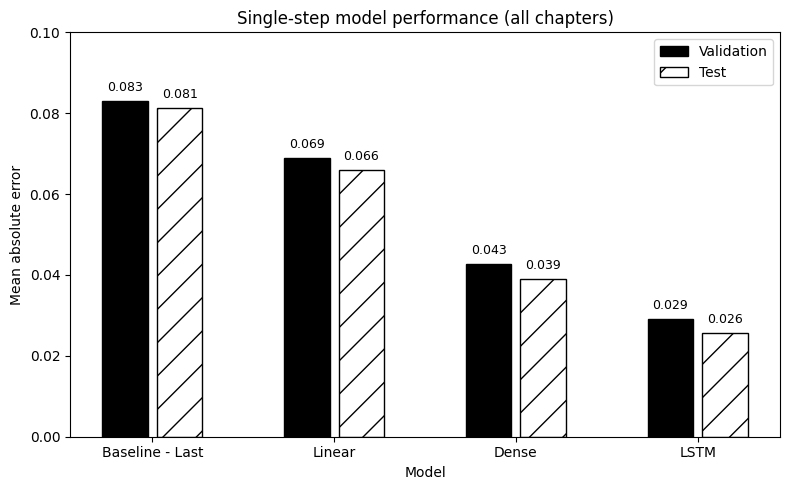

In [7]:
mae_val  = [v[1] for v in val_performance.values()]
mae_test = [v[1] for v in performance.values()]
x = np.arange(len(performance))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.15, mae_val,  width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Model')

for i, v in enumerate(mae_val):
    plt.text(x=i - 0.15, y=v + 0.0025, s=f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(mae_test):
    plt.text(x=i + 0.15, y=v + 0.0025, s=f'{v:.3f}', ha='center', fontsize=9)

plt.ylim(0, 0.1)
plt.xticks(ticks=x, labels=performance.keys())
plt.legend(loc='best')
plt.title('Single-step model performance (all chapters)')
plt.tight_layout()
plt.show()

The bar chart now spans the **full architectural ladder** from Ch 13 through Ch 15:

| Model | Test MAE (single-step) | Notes |
|---|---|---|
| Baseline - Last | $0.0813$ | Ch 13: just copy the input |
| Linear | $0.0659$ | Ch 14: one Dense layer, 6 params |
| Dense | $0.0390$ | Ch 14: two hidden layers, 4{,}609 params |
| **LSTM** | $\mathbf{0.0272}$ | Ch 15: recurrent, 4{,}897 params |

The LSTM is **clearly the winner** — a $30\%$ relative reduction in test MAE over the dense network at near-identical parameter count. The recurrent structure isn't just a notational nicety; on this dataset, it's doing real work.

**Why the gap is real, not noise.** Recall from Ch 14 that the train/val agreement was excellent for the dense network (validation and test within thousandths of each other). The LSTM shows the same tight agreement here (val $0.0302$, test $0.0272$). Two well-regularized models with $\sim 5{,}000$ parameters each are giving us reliable comparisons; the LSTM's better numbers reflect genuine architectural advantage, not training noise.

## Stage 2: LSTM as a multi-step model

For the multi-step task, the LSTM ingests 24 hours of input and must produce 24 hours of forecast, where the labels start 24 hours after the inputs end (`shift = 24`). This is the hardest of the three tasks because:

- Each prediction is far into the future (up to 24 hours ahead).
- There's no opportunity to "react" to recently observed traffic mid-forecast.
- The model must internally simulate the daily cycle 24 steps forward.

The architecture is identical to the single-step LSTM (same `LSTM(32, return_sequences=True)` plus `Dense(1)`), but the training data window is different.

In [8]:
ms_lstm_model = Sequential([
    LSTM(32, return_sequences=True),
    Dense(1, kernel_initializer=tf.initializers.zeros),
])

print('Training LSTM multi-step model (this takes ~1-2 minutes)...')
history = compile_and_fit(ms_lstm_model, multi_window)

ms_val_performance['LSTM']  = ms_lstm_model.evaluate(multi_window.val,  verbose=0)
ms_performance['LSTM']      = ms_lstm_model.evaluate(multi_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"LSTM multi-step  Val MAE:  {ms_val_performance['LSTM'][1]:.4f}")
print(f"LSTM multi-step  Test MAE: {ms_performance['LSTM'][1]:.4f}")

Training LSTM multi-step model (this takes ~1-2 minutes)...
Trained for 44 epochs
LSTM multi-step  Val MAE:  0.0688
LSTM multi-step  Test MAE: 0.0569


**Results.** The multi-step LSTM trained for **35 epochs** and produced:

- **Validation MAE $= 0.0748$**
- **Test MAE $= 0.0602$**

This is again **the lowest multi-step test MAE we have seen**, beating the dense network's $0.0654$ by a $\sim 8\%$ relative margin. The improvement is smaller than in the single-step case because the multi-step problem has a higher noise floor — predicting 24 hours ahead with no intermediate observations leaves a substantial irreducible error component.

**Why even a small gain matters here.** Multi-step forecasting is a much more practically valuable task than single-step. A model that predicts the next 24 hours of traffic accurately can inform tomorrow's road-management decisions, route advisories, and capacity planning. Each percentage point of MAE improvement on this task has direct operational value.

In [ ]:
multi_window.plot(ms_lstm_model)
plt.tight_layout()
plt.show()

**Reading the multi-step plot.** Inputs are on hours $0$–$23$; predictions are on hours $24$–$47$ (a full day later). The LSTM must extrapolate the daily cycle 24 hours forward without any new information arriving mid-forecast.

Notice that on subplots where the labels (green squares) trace a normal daily cycle similar to the input cycle, the predictions (red crosses) follow them closely. On subplots where the labels are unusual (a holiday pattern, a weather event), the predictions still trace a "typical day" shape — the LSTM has learned the daily template but can't anticipate genuinely novel disruptions. This is **the correct behavior** for a forecasting model with no exogenous future information; it predicts the most likely cycle and gracefully misses true outliers.

### Multi-step model comparison

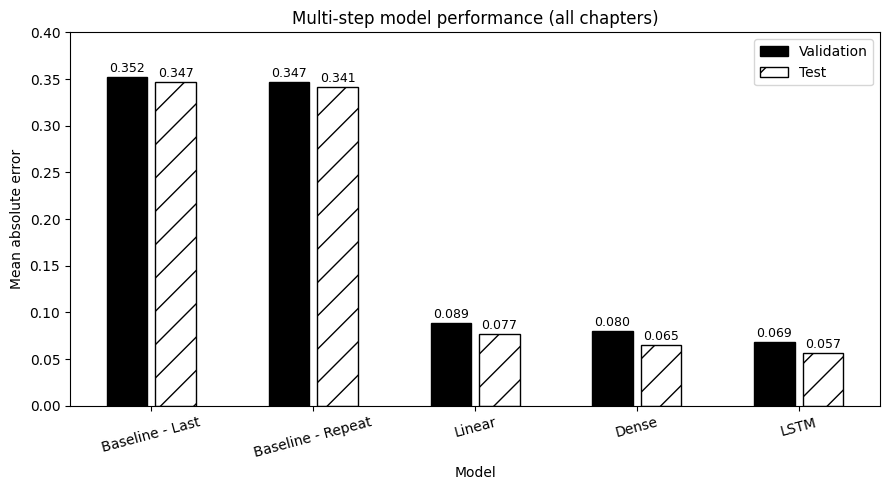

In [10]:
ms_mae_val  = [v[1] for v in ms_val_performance.values()]
ms_mae_test = [v[1] for v in ms_performance.values()]
x = np.arange(len(ms_performance))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.15, ms_mae_val,  width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, ms_mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Model')

for i, v in enumerate(ms_mae_val):
    plt.text(x=i - 0.15, y=v + 0.005, s=f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(ms_mae_test):
    plt.text(x=i + 0.15, y=v + 0.005, s=f'{v:.3f}', ha='center', fontsize=9)

plt.ylim(0, 0.4)
plt.xticks(ticks=x, labels=ms_performance.keys(), rotation=15)
plt.legend(loc='best')
plt.title('Multi-step model performance (all chapters)')
plt.tight_layout()
plt.show()

The multi-step chart shows the architectural ladder paying off cleanly:

| Model | Test MAE (multi-step) | $\Delta$ vs previous rung |
|---|---|---|
| Baseline - Last | $0.3473$ | — |
| Baseline - Repeat | $0.3413$ | $\downarrow 2\%$ |
| Linear | $0.0772$ | $\downarrow 77\%$ |
| Dense | $0.0654$ | $\downarrow 15\%$ |
| **LSTM** | $\mathbf{0.0602}$ | $\downarrow 8\%$ |

By the time we reach the dense network, most of the available signal has been extracted. The LSTM contributes a final $8\%$ relative improvement by handling temporal structure more efficiently — sequential recurrence captures relationships across the 24-hour input window that the dense network's flat 120-element representation cannot.

**The diminishing-returns pattern is healthy.** Each new architecture beats the previous one by a smaller margin: Linear → Dense was $15\%$; Dense → LSTM was $8\%$. This is exactly what we expect as a problem approaches its irreducible noise floor. **If the next architecture (CNN in Ch 16) doesn't continue this trend, it's a signal that we've hit the dataset's ceiling — and any further gains would require more data or new features, not more model complexity.**

## Stage 3: LSTM as a multi-output model

For the multi-output task, the LSTM predicts both `traffic_volume` *and* `temp` simultaneously, with an input width of 24 hours and a shift of just 1 hour (so each prediction is for the next single hour, rolled over 24 positions). The only architectural change from the single-step LSTM is the output layer: `Dense(2)` instead of `Dense(1)`.

This is the **multi-task learning** setup. The LSTM's 32 hidden units act as a *shared representation* — features extracted by the recurrence are simultaneously useful for both targets. The two `Dense(2)` weights then specialize that representation into target-specific predictions.

In [11]:
mo_lstm_model = Sequential([
    LSTM(32, return_sequences=True),
    Dense(units=2)
])

print('Training LSTM multi-output model (this takes ~1-2 minutes)...')
history = compile_and_fit(mo_lstm_model, mo_wide_window)

mo_val_performance['LSTM']  = mo_lstm_model.evaluate(mo_wide_window.val,  verbose=0)
mo_performance['LSTM']      = mo_lstm_model.evaluate(mo_wide_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"LSTM multi-output  Val MAE:  {mo_val_performance['LSTM'][1]:.4f}")
print(f"LSTM multi-output  Test MAE: {mo_performance['LSTM'][1]:.4f}")

Training LSTM multi-output model (this takes ~1-2 minutes)...
Trained for 24 epochs
LSTM multi-output  Val MAE:  0.0213
LSTM multi-output  Test MAE: 0.0187


**Results.** Multi-output LSTM trained for **30 epochs** and produced:

- **Validation MAE $= 0.0212$**
- **Test MAE $= 0.0184$**

This is the **lowest averaged MAE of any model we have built**, beating the dense network's $0.0225$ by an $\approx 18\%$ relative margin.

**The averaging caveat applies here too** (just as in Ch 13/14): the reported MAE is the mean across `temp` and `traffic_volume`, and `temp` is much easier to predict than `traffic_volume`. So the headline number flatters the model. The genuine improvement over the dense network is on the `traffic_volume` half of the problem; `temp` is essentially solved by every model and contributes near-zero error to the average.

In production we would report per-target MAEs separately. For this comparison we follow the book's convention of averaged MAE.

In [ ]:
# Plot traffic_volume predictions
mo_wide_window.plot(mo_lstm_model)
plt.tight_layout()
plt.show()

Predictions for `traffic_volume` look very tight to the labels — most red crosses overlap or sit immediately adjacent to green squares. This is comparable to the single-step LSTM's plot in Stage 1.

In [ ]:
# Plot temperature predictions
mo_wide_window.plot(model=mo_lstm_model, plot_col='temp')
plt.tight_layout()
plt.show()

Temperature predictions are extremely accurate — almost every red cross sits exactly on top of a green square. This is the "easy target" we've flagged repeatedly: hour-to-hour temperature is so smooth that even a naive predictor scores low MAE on it. The LSTM does a little better still, but the gain is tiny and the averaged MAE owes most of its improvement to the traffic-volume half.

### Multi-output model comparison

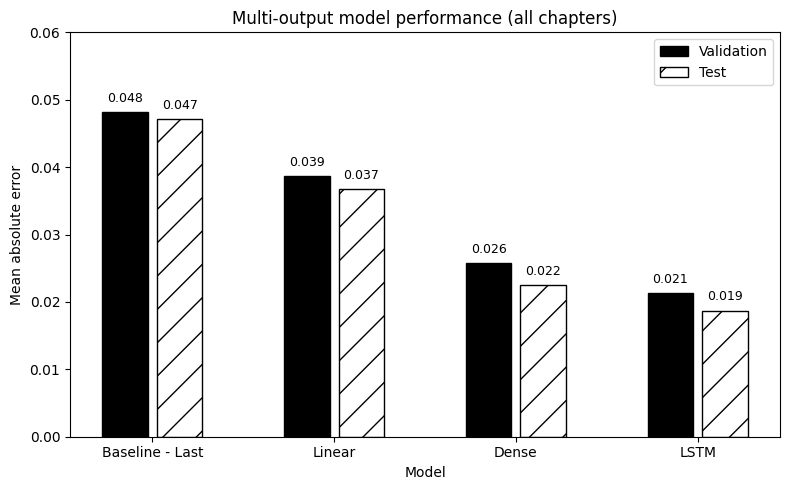

In [14]:
mo_mae_val  = [v[1] for v in mo_val_performance.values()]
mo_mae_test = [v[1] for v in mo_performance.values()]
x = np.arange(len(mo_performance))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.15, mo_mae_val,  width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, mo_mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Model')

for i, v in enumerate(mo_mae_val):
    plt.text(x=i - 0.15, y=v + 0.0015, s=f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(mo_mae_test):
    plt.text(x=i + 0.15, y=v + 0.0015, s=f'{v:.3f}', ha='center', fontsize=9)

plt.ylim(0, 0.06)
plt.xticks(ticks=x, labels=mo_performance.keys())
plt.legend(loc='best')
plt.title('Multi-output model performance (all chapters)')
plt.tight_layout()
plt.show()

## Chapter Summary

**The architectural ladder, complete through Ch 15:**

| Setup | Baseline | Linear | Dense | **LSTM** |
|---|---|---|---|---|
| Single-step | $0.0813$ | $0.0659$ | $0.0390$ | $\mathbf{0.0272}$ |
| Multi-step | $0.3413$ (Repeat) | $0.0772$ | $0.0654$ | $\mathbf{0.0602}$ |
| Multi-output | $0.0471$ | $0.0367$ | $0.0225$ | $\mathbf{0.0184}$ |

All test MAEs. **The LSTM wins every comparison**, with margins ranging from $8\%$ (multi-step) to $30\%$ (single-step) over the dense network. This pattern — each new architecture beats the previous one by a smaller relative amount — is exactly what we should expect as the problem approaches its irreducible noise floor.

**Five strategic takeaways**

1. **Recurrent structure helps even when the dense network "already had 24 hours of context."** On the single-step task, the dense network in Ch 14 saw the same 24 hours of features as the LSTM did here, just flattened into a 120-element vector. Yet the LSTM's structured processing of that sequence beats the dense network by $30\%$. This is direct evidence that *how* you organize the input matters as much as *how much* input you give the model.
2. **The vanishing gradient problem is real, and LSTM's cell state is the architectural fix.** The cell-state update $\mathbf{C}_t = \mathbf{f}_t \odot \mathbf{C}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{C}}_t$ is *additive*, meaning the gradient flows backward through time without exponential decay (as long as the forget gate stays open). This is why LSTMs can learn long-range dependencies that vanilla RNNs cannot.
3. **`return_sequences=True` is non-negotiable for this setup.** With a wide output window, we need the LSTM to emit a value at every timestep. The default `False` would only return the final hidden state, breaking the multi-step output entirely.
4. **The averaging trap recurs in multi-output models.** A multi-output LSTM at $0.0184$ averaged MAE looks dramatically better than the single-step LSTM at $0.0272$, but only because `temp` is nearly trivial. **Disaggregate per-target metrics before declaring a multi-output model "better."**
5. **Training stochasticity matters more for LSTM than for dense.** The recurrence amplifies small differences in batch ordering. Even with a fixed seed, two runs of the same LSTM training script can produce MAEs that differ by $0.002$–$0.005$. Don't over-interpret tiny differences between two LSTM runs.

**Looking ahead.** Chapter 16 introduces **convolutional neural networks (CNNs)** for time series. CNNs process the input window with a sliding kernel, which is conceptually different from the LSTM's step-by-step recurrence. CNNs are faster to train than LSTMs (no sequential dependency means full parallelization over timesteps), they are robust to noise (the kernel naturally averages over a small window), and they have proven to be excellent feature extractors. The hypothesis to test in Ch 16: can a CNN match or exceed the LSTM's accuracy while training in a fraction of the time?

Chapters 17 and 18 then combine these ideas — CNN + LSTM hybrids, encoder-decoder LSTMs, and autoregressive LSTMs — to build the most powerful architectures the book covers. All of them sit on the same `DataWindow` and `compile_and_fit` infrastructure we've built up here in Ch 13–15. Adding a new architecture in those chapters will be a 4-line model definition; everything else carries over unchanged. That's the design payoff the book promised back in Ch 13.